# Model Finetuning

The following notebook will finetune the model by training it on the sft datasets appositely created.

### Imports

In [1]:
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from datasets import load_from_disk
import re
from peft import LoraConfig, TaskType, PeftModel
from trl import SFTConfig, SFTTrainer
import json
import pandas as pd
import matplotlib.pyplot as plt



/mnt/data/envs/finetune-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Path definitions

In [3]:
PROJECT_ROOT = Path("/mnt/data/projects/Multilingual-Finetuning-Mistral-3B").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_SFT = DATA_PROCESSED / "sft"

ARTIFACTS_ROOT = Path("/mnt/data/project_artifacts")
MODEL_CACHE = ARTIFACTS_ROOT / "models_cache"
CHECKPOINT_DIR = ARTIFACTS_ROOT / "checkpoints"
LOGS_DIR = ARTIFACTS_ROOT / "logs"

for p in [DATA_SFT, MODEL_CACHE, CHECKPOINT_DIR, LOGS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PROCESSED:", DATA_PROCESSED)
print("DATA_SFT:", DATA_SFT)
print("ARTIFACTS_ROOT:", ARTIFACTS_ROOT)
print("MODEL_CACHE:", MODEL_CACHE)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)

train_sft_path = DATA_SFT / "train_sft"
validation_sft_path = DATA_SFT / "validation_sft"


PROJECT_ROOT: /mnt/data/projects/Multilingual-Finetuning-Mistral-3B
DATA_PROCESSED: /mnt/data/projects/Multilingual-Finetuning-Mistral-3B/data/processed
DATA_SFT: /mnt/data/projects/Multilingual-Finetuning-Mistral-3B/data/processed/sft
ARTIFACTS_ROOT: /mnt/data/project_artifacts
MODEL_CACHE: /mnt/data/project_artifacts/models_cache
CHECKPOINT_DIR: /mnt/data/project_artifacts/checkpoints


### Loading the datasets
After loading we run a quick sanity check.

In [33]:
train_sft = load_from_disk(train_sft_path)
validation_sft = load_from_disk(validation_sft_path)
print("Loaded existing SFT datasets.")

sample = train_sft[0]
for key, value in sample.items():
    print(key, ":", value)


Loaded existing SFT datasets.
language : English
language_code : eng
messages : [{'content': 'What is a data structure?', 'role': 'user'}, {'content': 'A data structure is a way of organizing and storing data to perform operations efficiently. It defines the relationships and functions that can be applied to the data.', 'role': 'assistant'}]


### Model loading
The next cell loads the, already downloaded, model that is going to be finetuned from the cache.

##### Padding

Padding tokens are special tokens added to sequences so that all inputs in a batch have the same length. This is necessary because models process data in fixed-size tensors.

The padding tokens are ignored by the model thanks to the mask used by the attention.

In [34]:
model_name = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    cache_dir=str(MODEL_CACHE),
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

print(type(tokenizer))
print("Pad token:", tokenizer.pad_token)


<class 'transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer'>
Pad token: <|endoftext|>


In [35]:
if torch.cuda.is_available():
    # GPU path
    chosen_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        cache_dir=str(MODEL_CACHE),
        torch_dtype=chosen_dtype,
        device_map="auto",
    )
else:
    # CPU path
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        cache_dir=str(MODEL_CACHE),
        torch_dtype=torch.float32,
        low_cpu_mem_usage=True,
    )

model.eval()

print("Model loaded.")
print(type(model))
print(type(tokenizer))
print("CUDA available:", torch.cuda.is_available())
print("First parameter dtype:", next(model.parameters()).dtype)


Loading weights: 100%|██████████| 434/434 [00:00<00:00, 6168.49it/s]


Model loaded.
<class 'transformers.models.qwen2.modeling_qwen2.Qwen2ForCausalLM'>
<class 'transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer'>
CUDA available: True
First parameter dtype: torch.bfloat16


### Training setup

We begin by defining the LoRA fine tuning setup, which consist in defining the low-rank matrices that are being trained.

This is the key idea: instead of training and reweighting the whole set of parameters we are only tuning a subset of the parameters.

This approach is more efficient and is cheaper in memory, storage and training time.

The full model defines a point in a very high-dimensional parameter manifold. Full fine-tuning would allow motion in the full tangent space of this manifold. LoRA instead restricts the deformation to a low-rank submanifold, where each adapted weight matrix receives a perturbation ΔW=BA of rank at most r. Training therefore optimizes a variational family of model perturbations rather than the full model. This is efficient because the pretrained model already contains the relevant multilingual features; the adapter learns a low-dimensional deformation that changes how those features are routed and expressed.

In [36]:
peft_config = LoraConfig(
    r=16,   # is the rank of the adapters, higher means more trianable capacity but more memory usage
    lora_alpha=32,  # scaling factor for the updates
    lora_dropout=0.05,  # dropout applied during training for the bit regularization
    bias="none",    # not training bias terms
    task_type=TaskType.CAUSAL_LM,  
    target_modules=[    # These will be the model sublayers where the LoRA adapters will be inserted (attention and MLP projection layers)
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)


#### Training Configuration

The following cell defines all the details setups and parameters that will be used during the training.

We performed instruction supervised fine tuning, by training a small set of LoRA adapter parameters gathered from the frozen base model. We minimized the language model negative log likelihood with reference to these parameters, by training the weights to assign higher probability to the correct continuation to the answers.

SFTTrainer uses the Hugging Face Trainer with AdamW to perform the gradient based optimization. We estimated the gradient of the loss on mini batches and consequently updated the trainable parameters.

This let's us understanding what finetuning actually means. We are not designing a model that directly improve its understanding of multilinguality, rather we define the model that maximized the likelihood of the correct response distribution on the given dataset.

In [9]:
run_name = "qwen25_3b_multilingual_lora_actual_run1"

training_args = SFTConfig(
    output_dir=str(CHECKPOINT_DIR / run_name),  # Where to save the outputs

    per_device_train_batch_size=1,  # how big the batches are
    per_device_eval_batch_size=1,   
    gradient_accumulation_steps=8,  # how often to evaluate and save

    learning_rate=2e-4, # the step size of the training optimization
    num_train_epochs=1, # per each epoch we have a full pass over the training set

    logging_steps=10,   # print logs each 10 steps
    eval_strategy="steps",
    eval_steps=50,  # run validation each 50 steps
    save_strategy="steps",
    save_steps=50,  # save checkpoints each 50 steps
    save_total_limit=2, # keep only the two most recent checkpoints so that storage does not explode

    load_best_model_at_end=True,    # After training reload the checkpoint with the best validation loss
    metric_for_best_model="eval_loss",  # The best checkpoint is chosen as a function of the validation loss
    greater_is_better=False,

    report_to="none",

    max_length=512,    # maximum tokenized sequence length used in training
    packing=False,     # do not concatenate multiple short samples into one sequence

    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),  # use mixed precision on GPU if available otherwise stay in full precision
)


##### Control Runs
Define some control flags to do some sanity check runs on subsets of the whole dataset.

In [38]:
PILOT_MODE = False
RUN_TRAINING = False   # keep False on CPU, switch to True when you are ready on GPU

train_sft_small = train_sft.shuffle(seed=42).select(
    range(min(300, len(train_sft)))
)

validation_sft_small = validation_sft.shuffle(seed=42).select(
    range(min(60, len(validation_sft)))
)

print(len(train_sft_small), len(validation_sft_small))


300 60


In [39]:
if PILOT_MODE:
    train_run_ds = train_sft_small
    validation_run_ds = validation_sft_small
else:
    train_run_ds = train_sft
    validation_run_ds = validation_sft

print("Train run size:", len(train_run_ds))
print("Validation run size:", len(validation_run_ds))


Train run size: 4882
Validation run size: 610


### Training
The following cells are the ones where the actual training takes part.

In [ ]:
if RUN_TRAINING and not torch.cuda.is_available():
    raise RuntimeError("GPU not available. Notebook setup is fine, but do not launch 3B fine-tuning on CPU.")

if RUN_TRAINING:
    trainer = SFTTrainer(
    model=model,        # base model to finetune
    args=training_args,     # Training settings defined before
    train_dataset=train_run_ds, # dataset used for training
    eval_dataset=validation_run_ds, # dataset used for validation
    processing_class=tokenizer, # the tokenizer used to process the text
    peft_config=peft_config,    # the LoRA configurations so that training will use adapters instead of doing a full fine-tuning
    )

    print(trainer)
    print("Output dir:", training_args.output_dir)
    print(trainer.model)
    trainer.model.print_trainable_parameters()

    trainer.train()     # ACTUAL TRAINING START COMMAND
else:
    print("RUN_TRAINING is False, so training is skipped.")

if RUN_TRAINING:
    trainer.save_model()    # saves the trained model
    tokenizer.save_pretrained(training_args.output_dir) # saves the tokenizer
    print("Saved model/tokenizer to:", training_args.output_dir)


RUN_TRAINING is False, so training is skipped.


### Training sucess testing
We run a quick manual inference test after the finetuning training.

#### Model loading from memory

In [10]:
run_dir = CHECKPOINT_DIR / run_name

print("Run directory:", run_dir)
print("Exists:", run_dir.exists())

checkpoint_dirs = sorted(
    run_dir.glob("checkpoint-*"),
    key=lambda p: int(p.name.split("-")[-1])
)

print("Found checkpoints:")
for ckpt in checkpoint_dirs:
    print(" ", ckpt.name)

if not checkpoint_dirs:
    raise ValueError(f"No checkpoint-* folders found inside {run_dir}")


Run directory: /mnt/data/project_artifacts/checkpoints/qwen25_3b_multilingual_lora_actual_run1
Exists: True
Found checkpoints:
  checkpoint-600
  checkpoint-611


In [11]:
best_checkpoint = None

for ckpt in checkpoint_dirs:
    trainer_state_file = ckpt / "trainer_state.json"
    
    if trainer_state_file.exists():
        with open(trainer_state_file, "r") as f:
            trainer_state = json.load(f)
        
        print("\nCheckpoint:", ckpt.name)
        print("Best model checkpoint:", trainer_state.get("best_model_checkpoint"))
        print("Best metric:", trainer_state.get("best_metric"))
        
        if trainer_state.get("best_model_checkpoint") is not None:
            best_checkpoint = Path(trainer_state["best_model_checkpoint"])

print("\nSelected best checkpoint:", best_checkpoint)



Checkpoint: checkpoint-600
Best model checkpoint: /mnt/data/project_artifacts/checkpoints/qwen25_3b_multilingual_lora_actual_run1/checkpoint-600
Best metric: 1.1618967056274414

Checkpoint: checkpoint-611
Best model checkpoint: /mnt/data/project_artifacts/checkpoints/qwen25_3b_multilingual_lora_actual_run1/checkpoint-611
Best metric: 1.161696195602417

Selected best checkpoint: /mnt/data/project_artifacts/checkpoints/qwen25_3b_multilingual_lora_actual_run1/checkpoint-611


In [12]:
adapter_path = best_checkpoint

print("Adapter path:", adapter_path)
print("Exists:", adapter_path.exists())
print("Adapter config exists:", (adapter_path / "adapter_config.json").exists())


Adapter path: /mnt/data/project_artifacts/checkpoints/qwen25_3b_multilingual_lora_actual_run1/checkpoint-611
Exists: True
Adapter config exists: True


In [46]:
base_model_id = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    base_model_id,
    cache_dir=MODEL_CACHE,
    trust_remote_code=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    cache_dir=MODEL_CACHE,
    device_map="auto",
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    trust_remote_code=True,
)

model = PeftModel.from_pretrained(
    base_model,
    adapter_path,
)

model.eval()

print("Fine-tuned LoRA model loaded successfully.")
print("Loaded adapter from:", adapter_path)


Loading weights: 100%|██████████| 434/434 [00:00<00:00, 5435.66it/s]


Fine-tuned LoRA model loaded successfully.
Loaded adapter from: /mnt/data/project_artifacts/checkpoints/qwen25_3b_multilingual_lora_actual_run1/checkpoint-611


In [ ]:
messages = [sample["messages"][0]]

prompt_text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

print(prompt_text)


inputs = tokenizer(prompt_text, return_tensors="pt")
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model.generate(   # UPDATE: the previous cells loads the model, so now it will always work, even after rebooting. --- If the training was successfull then trainer.model now contains the LoRA adapted trained version. Note this works only within the same notebook session where you do not need to reload the finetuned model, because the finetuned model object is already inside the trainer.
        # The model variable contains the reloaded base model plus the fine-tuned LoRA adapter.
# Therefore, after restarting the notebook, inference should use model.generate().
        **inputs,
        max_new_tokens=64,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )

prompt_len = inputs["input_ids"].shape[1]
generated_tokens = outputs[0][prompt_len:]

prediction = tokenizer.decode(generated_tokens, skip_special_tokens=True)

print("PREDICTION:\n", prediction)
print("\nTARGET:\n", sample["messages"][1]["content"])


<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
What is a data structure?<|im_end|>
<|im_start|>assistant



PREDICTION:
 A data structure is a way of organizing and storing data in a computer so that it can be accessed and used efficiently.

TARGET:
 A data structure is a way of organizing and storing data to perform operations efficiently. It defines the relationships and functions that can be applied to the data.


#### Training diagnostics from `trainer_state.json`

After fine-tuning, Hugging Face saves a `trainer_state.json` file containing the training log history.  
Here I load this file, convert the logged events into a pandas DataFrame, and extract the training and validation loss values recorded during training.

The training loss indicates how well the LoRA adapter fits the training examples.  
The validation loss measures whether this improvement transfers to held-out examples.

Plotting both curves helps diagnose whether the model learned useful structure or simply overfit the training set.

In [ ]:
state_file = adapter_path / "trainer_state.json"    # path to the file

with open(state_file, "r") as f:
    trainer_state = json.load(f)    # file containing all the metadata

log_history = trainer_state["log_history"]

df_logs = pd.DataFrame(log_history)

df_logs.head()


,entropy,epoch,grad_norm,learning_rate,loss,mean_token_accuracy,num_tokens,step,eval_entropy,eval_loss,eval_mean_token_accuracy,eval_num_tokens,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,1.463158,0.016387,0.870659,0.000197,1.950968,0.637632,13746.0,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.344886,0.032773,0.486855,0.000194,1.405312,0.705043,25518.0,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.376374,0.049160,0.448499,0.000191,1.565218,0.689621,39073.0,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.376116,0.065547,0.596004,0.000187,1.538760,0.698669,51441.0,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.378679,0.081934,0.489448,0.000184,1.518499,0.686373,65435.0,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Separating training loss and evaluation loss
train_loss_df = df_logs[df_logs["loss"].notna()][["step", "epoch", "loss"]].copy()
eval_loss_df = df_logs[df_logs["eval_loss"].notna()][["step", "epoch", "eval_loss"]].copy()

print("Training loss points:")
display(train_loss_df.tail())

print("Validation loss points:")
display(eval_loss_df.tail())


Training loss points:


,step,epoch,loss
67,570,0.934043,1.361636
68,580,0.950430,1.401922
69,590,0.966817,1.296102
70,600,0.983204,1.342068
72,610,0.999590,1.204140


Validation loss points:


,step,epoch,eval_loss
53,450,0.737403,1.172737
59,500,0.819336,1.167855
65,550,0.901270,1.164409
71,600,0.983204,1.161897
73,611,1.000000,1.161696


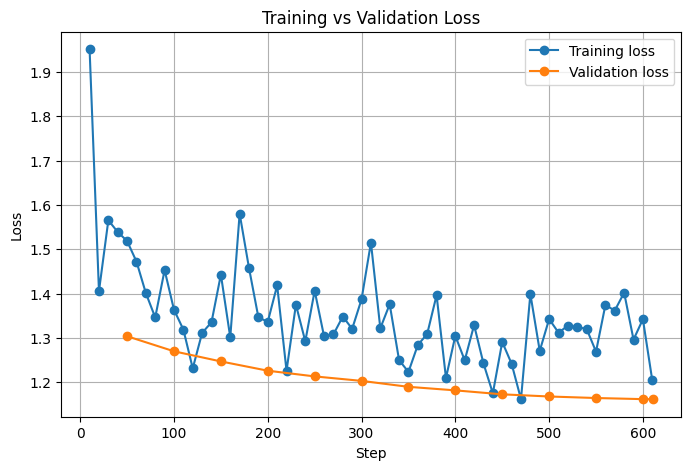

In [15]:
# Plotting training vs validation loss
plt.figure(figsize=(8, 5))

plt.plot(train_loss_df["step"], train_loss_df["loss"], marker="o", label="Training loss")
plt.plot(eval_loss_df["step"], eval_loss_df["eval_loss"], marker="o", label="Validation loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
first_train_loss = train_loss_df["loss"].iloc[0]
last_train_loss = train_loss_df["loss"].iloc[-1]

first_eval_loss = eval_loss_df["eval_loss"].iloc[0]
last_eval_loss = eval_loss_df["eval_loss"].iloc[-1]

print(f"Training loss:   {first_train_loss:.4f} → {last_train_loss:.4f}")
print(f"Validation loss: {first_eval_loss:.4f} → {last_eval_loss:.4f}")

# Evaluation of training logs with proper comments:

if last_eval_loss < first_eval_loss:
    print("Validation loss improved: good sign.")
else:
    print("Validation loss did not improve: possible overfitting or weak learning.")

if last_train_loss < first_train_loss and last_eval_loss > first_eval_loss:
    print("Training loss decreased but validation loss increased: possible overfitting.")


Training loss:   1.9510 → 1.2041
Validation loss: 1.3037 → 1.1617
Validation loss improved: good sign.


The training logs show that the LoRA fine-tuning run learned in a stable way. The training loss decreased from **1.9510** to **1.2041**, indicating that the adapter parameters became better at fitting the supervised multilingual training examples. More importantly, the validation loss also decreased from **1.3037** to **1.1617**, which suggests that the improvement was not limited to memorizing the training set, but also transferred to held-out validation data.

This is a good first sanity check for the fine-tuning run: the optimization behaved as expected, and there is no classic sign of overfitting, since both training and validation loss improved. Further evaluation is still needed using exact match, semantic similarity, token overlap, and manual inspection, because lower language-modeling loss does not automatically imply better task-level answers.